# Logistic Regression at Full Scale, and Evaluation

### Table of contents
0. [Introduction](#0.-Introduction)
1. [The dataset: Breast Cancer Wisconsin](#1.-The-dataset:-Breast-Cancer-Wisconsin)
2. [A quick look at the data](#2.-A-quick-look-at-the-data)
3. [Train/test split](#3.-Train/test-split)
4. [Scaling](#4.-Scaling)
5. [Logistic Regression, at full scale](#5.-Logistic-Regression,-at-full-scale)
6. [Decision boundary, visually](#6.-Decision-boundary,-visually)
7. [Threshold tuning](#7.-Threshold-tuning)
8. [Evaluation metrics, fully covered](#8.-Evaluation-metrics,-fully-covered)
9. [Summary](#9.-Summary)

## 0. Introduction

Notebook 1 built Logistic Regression on 10 rows. Same model, same API, now on 569 samples and 30 features. This time evaluation gets the full treatment: confusion matrix, precision/recall/F1, class imbalance, the precision/recall trade-off, and ROC/AUC.

## 1. The dataset: Breast Cancer Wisconsin

A single-call, `scikit-learn`-loadable dataset. From measurements of a breast mass's cell nuclei, predict malignant or benign.

In [1]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
df = data.frame
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Encoding: `0 = malignant`, `1 = benign`. Worth checking explicitly, since flipping this by accident silently inverts every precision/recall number later.

In [2]:
print(f"0 -> {data.target_names[0]}")
print(f"1 -> {data.target_names[1]}")

0 -> malignant
1 -> benign


## 2. A quick look at the data

Same checklist as weeks 2 and 3: shape, missing values, class balance.

In [3]:
print("Shape:", df.shape)
df.isna().sum().sum()

Shape: (569, 31)


np.int64(0)

In [4]:
df["target"].value_counts().rename(index={0: "malignant (0)", 1: "benign (1)"})

target
benign (1)       357
malignant (0)    212
Name: count, dtype: int64

No missing values. Classes are moderately imbalanced (about 63% benign), mild here, but section 8.2 pushes this further.

In [5]:
corr_with_target = df.drop(columns="target").corrwith(df["target"]).sort_values()
corr_with_target.head(5)

worst concave points   -0.793566
worst perimeter        -0.782914
mean concave points    -0.776614
worst radius           -0.776454
mean perimeter         -0.742636
dtype: float64

Most negative correlations: `worst concave points`, `worst radius`. Negative because `target=1` is benign, so larger, rougher tumors push toward malignant.

## 3. Train/test split

Split before touching the model. For classification, also pass `stratify=y` so train and test keep the same class proportions.

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
print("Train size:", X_train.shape[0], " benign fraction:", y_train.mean().round(3))
print("Test size: ", X_test.shape[0], " benign fraction:", y_test.mean().round(3))

Train size: 455  benign fraction: 0.626
Test size:  114  benign fraction: 0.632


## 4. Scaling

Fit the scaler on train only. Logistic Regression tolerates unscaled features reasonably well, but scaling here keeps the comparison with KNN fair in notebook 5.

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Logistic Regression, at full scale

Same class as notebook 1, now on 455 training samples and 30 scaled features.

In [9]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=5000)
logreg.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [10]:
y_pred = logreg.predict(X_test_scaled)
y_proba = logreg.predict_proba(X_test_scaled)

print("Shape of predict_proba output:", y_proba.shape)
print("First 5 predictions:      ", y_pred[:5])
print("First 5 P(benign) values: ", y_proba[:5, 1].round(3))

Shape of predict_proba output: (114, 2)
First 5 predictions:       [0 1 0 1 0]
First 5 P(benign) values:  [0.    1.    0.006 0.534 0.   ]


Column 1 of `predict_proba` is `P(benign)`. `predict()` is that column at `>= 0.5`. Which features push the prediction most?

In [11]:
import pandas as pd

coefs = pd.Series(logreg.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
coefs.head(8)

worst texture          -1.255088
radius error           -1.082965
worst concave points   -0.953686
worst area             -0.947756
worst radius           -0.947616
worst symmetry         -0.939181
area error             -0.929104
worst concavity        -0.823151
dtype: float64

A coefficient: holding other scaled features fixed, a one-std-dev increase in this feature shifts the log-odds of benign by this much. Positive pushes toward benign, negative toward malignant.

Is the test-set score a fluke of this one split? `cross_val_score` refits across several folds:

In [12]:
from sklearn.model_selection import cross_val_score

cv_accuracy = cross_val_score(logreg, X_train_scaled, y_train, cv=5, scoring="accuracy")
print("Per-fold accuracy:", cv_accuracy.round(4))
print(f"Mean: {cv_accuracy.mean():.4f}  Std: {cv_accuracy.std():.4f}")

Per-fold accuracy: [0.967 0.978 0.967 1.    0.989]
Mean: 0.9802  Std: 0.0128


A small std across folds means the section 8 test-set number is trustworthy, not a lucky split.

## 6. Decision boundary, visually

30 features can't be plotted. Switch to synthetic 2D data (`make_moons`) to see a boundary directly. Reused for the same purpose in notebooks 3 and 4.

In [13]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=300, noise=0.25, random_state=42)
lr_moons = LogisticRegression().fit(X_moons, y_moons)

In [14]:
import numpy as np

def plot_boundary(ax, model, X, y, title, proba_thresh=0.5):
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap="RdBu_r", alpha=0.6)
    ax.contour(xx, yy, Z, levels=[proba_thresh], colors="black", linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu_r", edgecolors="white", linewidths=0.6, s=25)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

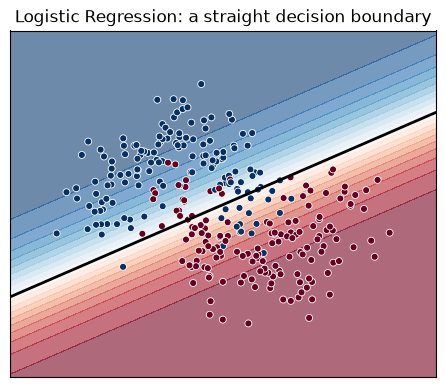

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5.5, 4.5))
plot_boundary(ax, lr_moons, X_moons, y_moons, "Logistic Regression: a straight decision boundary")
plt.show()

The shading is `P(class 1)`. The black line is where it crosses 0.5, the boundary. It's always a straight line, since `z = w*x + b` is linear. KNN and Decision Trees (notebooks 3 and 4) don't have this restriction.

## 7. Threshold tuning

`predict()` always uses 0.5. Pick any threshold directly from `predict_proba`:

In [16]:
from sklearn.metrics import recall_score

for threshold in [0.3, 0.5, 0.7]:
    y_pred_t = (y_proba[:, 1] >= threshold).astype(int)
    n_predicted_benign = y_pred_t.sum()
    print(f"threshold={threshold}:  predicted benign = {n_predicted_benign:3d} / {len(y_pred_t)}"
          f"   recall(malignant) = {recall_score(y_test, y_pred_t, pos_label=0):.3f}")

threshold=0.3:  predicted benign =  74 / 114   recall(malignant) = 0.952
threshold=0.5:  predicted benign =  72 / 114   recall(malignant) = 0.976
threshold=0.7:  predicted benign =  68 / 114   recall(malignant) = 0.976


A lower threshold means fewer "benign" calls, so recall on malignant (`pos_label=0`) rises: the model gets more cautious about missing a real case.

## 8. Evaluation metrics, fully covered

### 8.1 Confusion Matrix, Precision, Recall, F1

Notebook 1 hand-counted these on 10 rows. Same idea, computed by `scikit-learn`, on the full 114-sample test set at the default threshold.

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

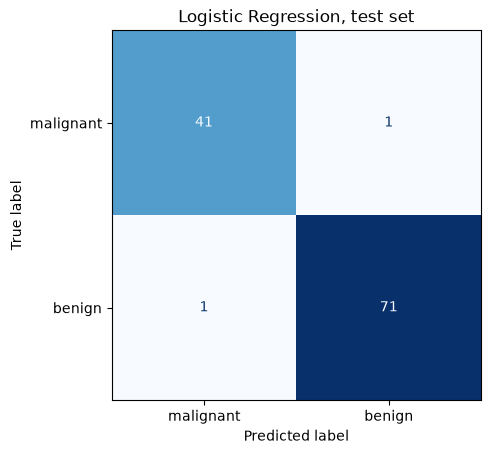

In [18]:
ConfusionMatrixDisplay(cm, display_labels=data.target_names).plot(cmap="Blues", colorbar=False)
plt.title("Logistic Regression, test set")
plt.show()

In [19]:
from sklearn.metrics import accuracy_score, precision_score, f1_score

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")

Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
F1-score:  0.9861


All four are high, an easy dataset for a linear model. The next part builds a case where a high number hides a useless model.

### 8.2 When accuracy lies: class imbalance

A deliberately extreme case: 950 healthy, 50 disease samples.

In [20]:
from sklearn.dummy import DummyClassifier

y_imbalanced = np.array([0] * 950 + [1] * 50)  # 0 = healthy, 1 = disease
dummy = DummyClassifier(strategy="constant", constant=0)
dummy.fit(np.zeros((len(y_imbalanced), 1)), y_imbalanced)
y_dummy_pred = dummy.predict(np.zeros((len(y_imbalanced), 1)))

In [21]:
print(f"Accuracy:            {accuracy_score(y_imbalanced, y_dummy_pred):.2%}")
print(f"Recall (disease=1):  {recall_score(y_imbalanced, y_dummy_pred):.2%}")

Accuracy:            95.00%
Recall (disease=1):  0.00%


95% accuracy, 0% recall on the class that matters: the model never predicts disease. Whenever classes are imbalanced, check precision, recall, and F1 per class, not just accuracy.

### 8.3 The Precision/Recall trade-off

`precision_recall_curve` computes precision and recall at every threshold, not just the three from section 7.

In [22]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_proba[:, 1])

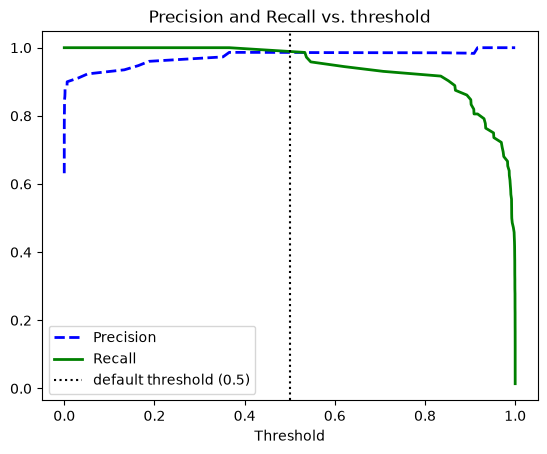

In [23]:
plt.plot(pr_thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(pr_thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.axvline(0.5, color="black", linestyle=":", label="default threshold (0.5)")
plt.xlabel("Threshold")
plt.legend(loc="lower left")
plt.title("Precision and Recall vs. threshold")
plt.show()

As the threshold rises, precision goes up and recall goes down. No threshold maximizes both. Same information, recall against precision directly:

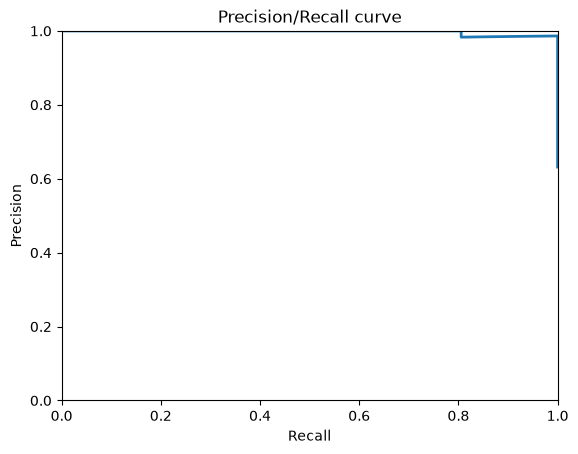

In [24]:
plt.plot(recalls, precisions, linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision/Recall curve")
plt.axis([0, 1, 0, 1])
plt.show()

A curve near the top-right corner means high precision and recall are achievable together. Suppose we need at least 98% precision. Find the lowest threshold that still hits it:

In [25]:
idx_98 = (precisions >= 0.98).argmax()
threshold_98 = pr_thresholds[idx_98]
recall_at_98 = recalls[idx_98]

print(f"Threshold for >=98% precision: {threshold_98:.3f}")
print(f"Recall at that threshold:      {recall_at_98:.3f}")

Threshold for >=98% precision: 0.366
Recall at that threshold:      1.000


### 8.4 ROC curve and AUC

A complementary view: true positive rate vs. false positive rate, across every threshold.

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_proba[:, 1])
auc_score = roc_auc_score(y_test, y_proba[:, 1])

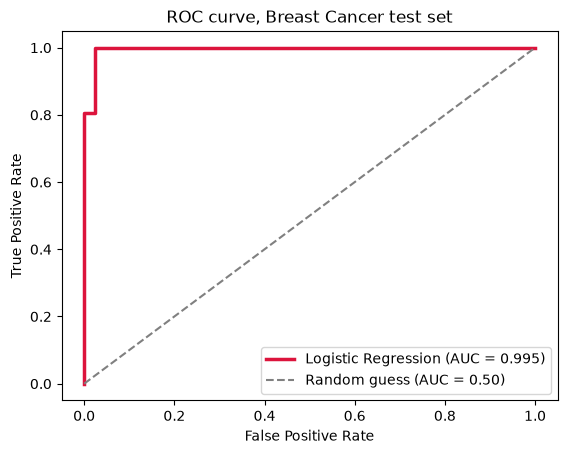

In [27]:
plt.plot(fpr, tpr, color="crimson", linewidth=2.5, label=f"Logistic Regression (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random guess (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve, Breast Cancer test set")
plt.legend(loc="lower right")
plt.show()

AUC near 1.0 means near-perfect separation across essentially every threshold. Its main use is comparing models without committing to one threshold, exactly what notebook 5 does.

## 9. Summary

- Same Logistic Regression from notebook 1, now at 455 training samples and 30 scaled features instead of 10 rows and 1 feature.
- The decision boundary is always linear.
- Accuracy alone can mislead, especially under class imbalance. Check precision, recall, and F1 per class.
- The precision/recall trade-off and ROC/AUC both summarize performance across every threshold at once.

Notebook 3 introduces a completely different classifier, KNN, starting the same way this week started: on a handful of points, by hand.